### 🧠 CELL 1: Import Library & System Setup


In [1]:
# ─────────────────────────────────────────────
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG19, InceptionV3, MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print(f"✅ TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU available: {len(gpus) > 0}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ Memory growth enabled for {len(gpus)} GPU(s)")


# ─────────────────────────────────────────────

✅ TensorFlow version: 2.10.0
✅ GPU available: True
✅ Memory growth enabled for 1 GPU(s)


### 🧠 CELL 2: Konfigurasi Path & Hyperparameter


In [ ]:
# ─────────────────────────────────────────────
if os.name == 'posix':
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'

FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')

IMG_DIR = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')

MODEL_DIR = os.path.join(BASE_DIR, 'models_temp', 'lightweight')
#LOG_DIR   = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'lightweight', 'logs')
LOG_DIR = os.path.join(BASE_DIR, 'models_temp', 'lightweight', 'logs_temp')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

EPOCHS      = 5     # Bisa dinaikkan ke 20-30 jika hasilnya belum saturasi
BATCH_SIZE  = 64     # Sangat aman untuk RTX 4060 Ti 16GB
LR          = 1e-4
PATIENCE    = 3

MODEL_CONFIGS = {
    'resnet50': {
        'class'     : ResNet50,
        'input_size': (224, 224),
        'preprocess': tf.keras.applications.resnet50.preprocess_input,
    },
    'vgg19': {
        'class'     : VGG19,
        'input_size': (224, 224),
        'preprocess': tf.keras.applications.vgg19.preprocess_input,
    },
    'inceptionv3': {
        'class'     : InceptionV3,
        'input_size': (299, 299),
        'preprocess': tf.keras.applications.inception_v3.preprocess_input,
    },
    'mobilenetv3': {
        'class'     : MobileNetV3Large,
        'input_size': (224, 224),
        'preprocess': tf.keras.applications.mobilenet_v3.preprocess_input,
    },
}

print("✅ Config loaded!")
print(f"📁 Model akan disimpan di: {MODEL_DIR}")


# ─────────────────────────────────────────────

✅ Config loaded!
📁 Model akan disimpan di: D:\Antigravity\Visual Based Rekomender Sistem\models_temp\lightweight


### 🧠 CELL 3: Load Data Training (Dari full_dataset)


In [3]:
# ─────────────────────────────────────────────
print("\n📦 Memuat dataset training...")
df_full = pd.read_csv(FULL_CSV)

# Ubah nama file gambar menjadi path fix untuk Windows/Linux
df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1))) if str(x).startswith('img/') else os.path.join(IMG_DIR, os.path.normpath(str(x)))
)

# Ambil HANYA yang split='train' untuk proses belajar fine-tuning
df_train_all = df_full[df_full['split'] == 'train'].copy()

# Filter kategori yang kemunculannya terlalu sedikit
cat_counts = df_train_all['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df_train_all = df_train_all[df_train_all['category'].isin(valid_cats)].reset_index(drop=True)

# Encode kategori menjadi angka berurutan (0, 1, 2, ...) untuk TensorFlow
label_enc = LabelEncoder()
df_train_all['category_idx'] = label_enc.fit_transform(df_train_all['category'])
num_classes = len(label_enc.classes_)

print(f"📊 Total gambar training : {len(df_train_all):,}")
print(f"📊 Jumlah kelas kategori : {num_classes}")

# Split 80/20 untuk set validasi awal
train_df, val_df = train_test_split(
    df_train_all, 
    test_size=0.2, 
    stratify=df_train_all['category_idx'], 
    random_state=42
)

# Keras ImageDataGenerator butuh label berbentuk string
train_df['category_str'] = train_df['category_idx'].astype(str)
val_df['category_str']   = val_df['category_idx'].astype(str)


# ─────────────────────────────────────────────


📦 Memuat dataset training...
📊 Total gambar training : 25,867
📊 Jumlah kelas kategori : 16


### 🧠 CELL 4: Fungsi Utility (Model & Generator)


In [4]:
# ─────────────────────────────────────────────
def build_finetune_model(cfg, num_classes):
    """Membangun arsitektur: Base model (frozen) + Head (Trainable Dense 512)."""
    # 1. Base model FROZEN
    base_model = cfg['class'](weights='imagenet', include_top=False, input_shape=cfg['input_size']+(3,))
    base_model.trainable = False
    
    # 2. Custom Head ("The Lightweight Part")
    x = GlobalAveragePooling2D()(base_model.output)
    
    # KUNCI UTAMA: Layer 512-D ini akan ditarik fiturnya (menjadi embedding)
    x = Dense(512, activation='relu', name='feature_embedding')(x)
    x = Dropout(0.3)(x)
    
    # 3. Layer Klasifikasi Akhir
    outputs = Dense(num_classes, activation='softmax', name='classification_head')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_data_generators(cfg, train_df, val_df):
    """Menghasilkan pipeline data dengan Augmentasi Gambar."""
    train_datagen = ImageDataGenerator(
        preprocessing_function=cfg['preprocess'],
        horizontal_flip=True,
        rotation_range=15,
        zoom_range=0.2,       # Zoom in/out random 20%
        shear_range=0.1
    )
    val_datagen = ImageDataGenerator(
        preprocessing_function=cfg['preprocess']
    )
    
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='full_path',
        y_col='category_str',
        target_size=cfg['input_size'],
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=True
    )
    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='full_path',
        y_col='category_str',
        target_size=cfg['input_size'],
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=False
    )
    return train_gen, val_gen


# ─────────────────────────────────────────────

### 🧠 CELL 5: Fine-Tuning Training Loop


In [5]:
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  🚀 MEMULAI FINE-TUNING (TRAINING HEAD)")
print("="*55)

histories = {}

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n🧠 Model: {model_name.upper()}")
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}_finetuned.h5")
    log_path   = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")
    
    if os.path.exists(model_path):
        print(f"  ⏩ Model weight sudah ada, skipping training...")
        continue
        
    train_gen, val_gen = get_data_generators(cfg, train_df, val_df)
    model = build_finetune_model(cfg, num_classes)
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss'),
        CSVLogger(log_path, append=False)
    ]
    
    print(f"  ▶️ Memulai training {EPOCHS} Epochs...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        workers=4,
        max_queue_size = 100
    )
    
    histories[model_name] = history.history
    print(f"  ✅ Training selesai! Model tersimpan di {model_path}")
    
    # Cleanup memory
    del model, train_gen, val_gen
    gc.collect()
    tf.keras.backend.clear_session()

print("\n🎉 SELURUH PROSES FINE-TUNING LOKAL SELESAI!")


# ─────────────────────────────────────────────


  🚀 MEMULAI FINE-TUNING (TRAINING HEAD)

🧠 Model: RESNET50
Found 20693 validated image filenames belonging to 16 classes.
Found 5174 validated image filenames belonging to 16 classes.
  ▶️ Memulai training 5 Epochs...
Epoch 1/5
647/647 [==============================] - 74s 104ms/step - loss: 1.6111 - accuracy: 0.4614 - val_loss: 1.2455 - val_accuracy: 0.5725
Epoch 2/5
647/647 [==============================] - 55s 85ms/step - loss: 1.2812 - accuracy: 0.5535 - val_loss: 1.1306 - val_accuracy: 0.6017
Epoch 3/5
647/647 [==============================] - 55s 85ms/step - loss: 1.1792 - accuracy: 0.5858 - val_loss: 1.0662 - val_accuracy: 0.6231
Epoch 4/5
647/647 [==============================] - 55s 85ms/step - loss: 1.1173 - accuracy: 0.6057 - val_loss: 1.0491 - val_accuracy: 0.6320
Epoch 5/5
647/647 [==============================] - 55s 85ms/step - loss: 1.0649 - accuracy: 0.6210 - val_loss: 1.0028 - val_accuracy: 0.6467
  ✅ Training selesai! Model tersimpan di D:\Antigravity\Visual Ba

### 🧠 CELL 6: Visualisasi Performa Training (Loss & Accuracy)


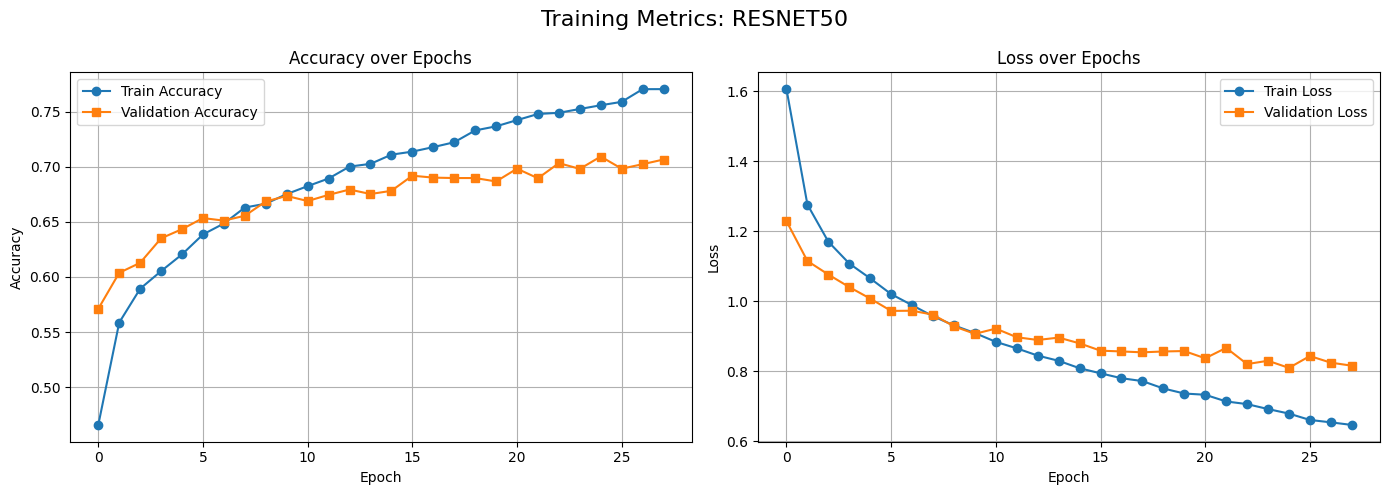

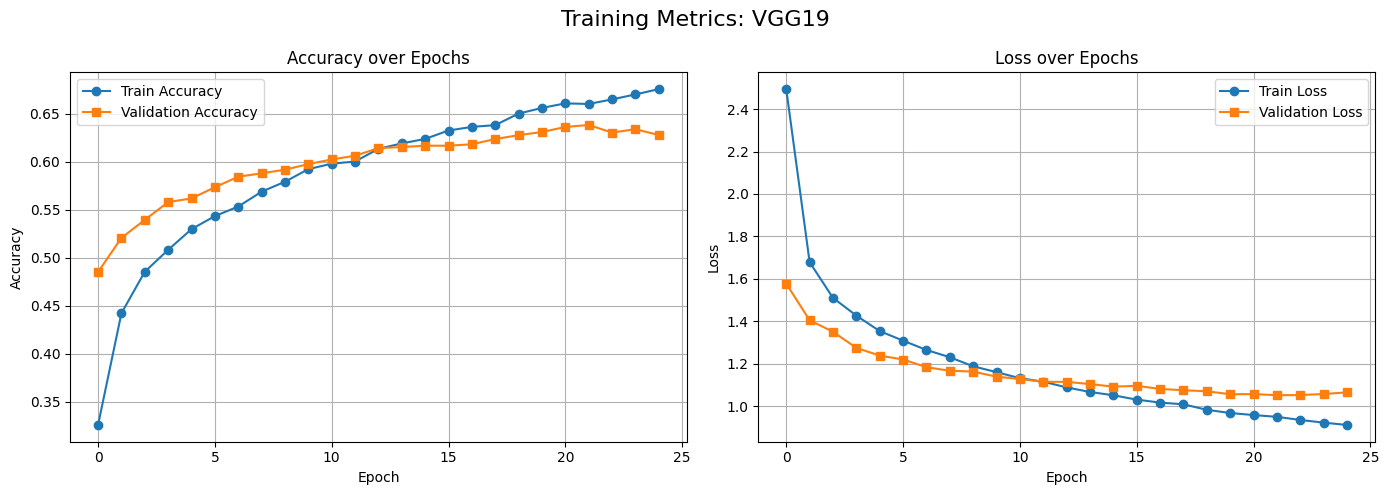

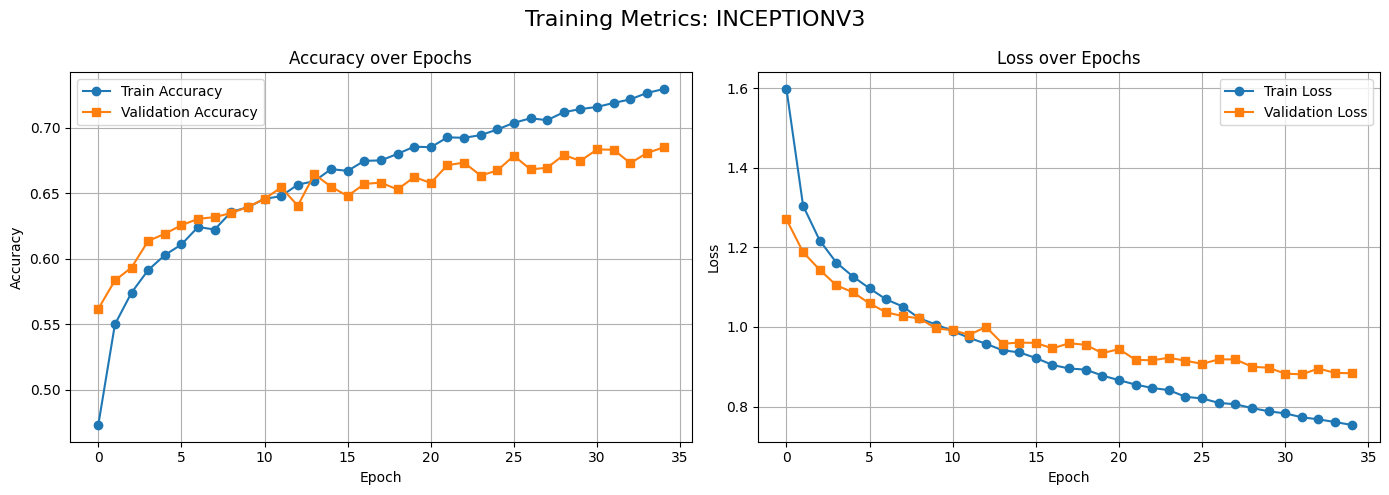

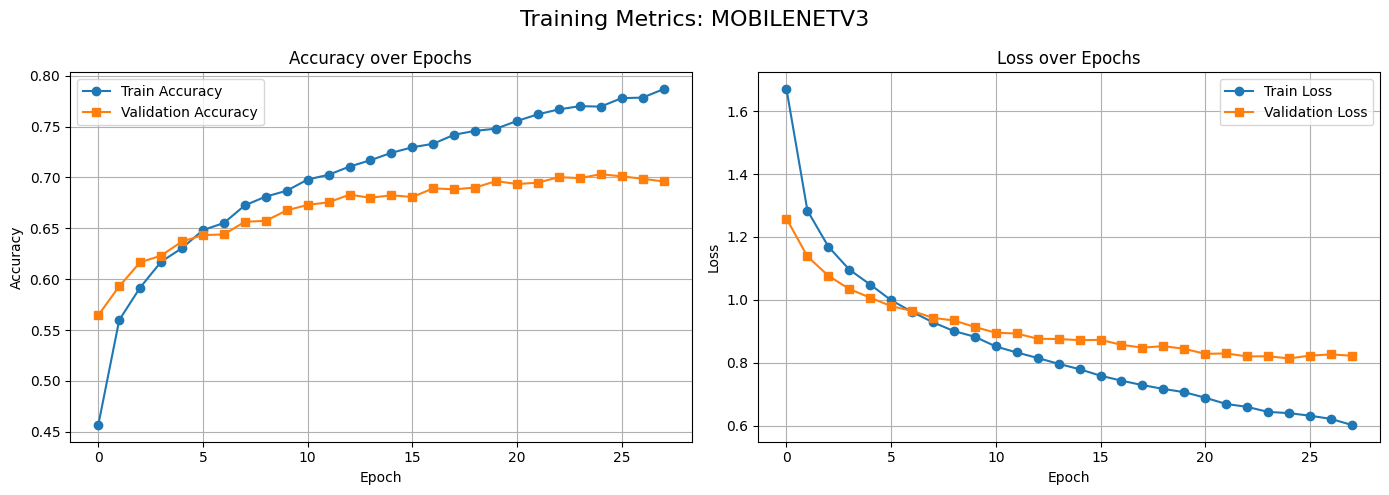

In [8]:
# ─────────────────────────────────────────────
for model_name in MODEL_CONFIGS.keys():
    log_path = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Training Metrics: {model_name.upper()}', fontsize=16)
        
        # Accuracy plot
        ax[0].plot(df_log['epoch'], df_log['accuracy'], label='Train Accuracy', marker='o')
        ax[0].plot(df_log['epoch'], df_log['val_accuracy'], label='Validation Accuracy', marker='s')
        ax[0].set_title('Accuracy over Epochs')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Accuracy')
        ax[0].legend()
        ax[0].grid(True)
        
        # Loss plot
        ax[1].plot(df_log['epoch'], df_log['loss'], label='Train Loss', marker='o')
        ax[1].plot(df_log['epoch'], df_log['val_loss'], label='Validation Loss', marker='s')
        ax[1].set_title('Loss over Epochs')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Loss')
        ax[1].legend()
        ax[1].grid(True)
        
        plt.tight_layout()
        plt.show()